# GAN Assignment — Combined Notebook

All code from Part 1 and Part 2 (2.1 OCTMNIST, 2.2 CICIDS2017, 2.3 QuickDraw) stitched into a single runnable notebook, in dependency order:

1. Part 1 — 2D GANs from scratch (sine wave + Gaussian mixture + architecture comparison)
2. Shared DCGAN components (used by 2.1 and 2.3)
3. FID utilities (used by 2.1 and 2.3)
4. Part 2.1 — OCTMNIST DCGAN (+ optional conditional-GAN extension)
5. Part 2.2 — CICIDS2017 tabular GAN
6. Part 2.3 — QuickDraw 'birthday cake' DCGAN (+ multi-category extension)

**Before running:** install dependencies and, for Part 2, download the datasets (see the markdown notes in each section — none of this was executed in the environment that generated this notebook, so run top-to-bottom yourself).

```
pip install torch torchvision medmnist pandas scikit-learn scipy matplotlib
```

---
# Part 1: 2D GANs from scratch

Part 1 - Building and Understanding GANs from Scratch
======================================================

Reproduces the sine-wave GAN from the tutorial, extends it to a new 2D
distribution (a mixture of 5 Gaussians), and compares the baseline
architecture against a modified one (deeper network + Tanh activations)
on the harder, multi-modal distribution.

Why a Gaussian mixture as the "new distribution"?
The sine wave and the noisy-parametric-curve option are both single,
connected 1D manifolds embedded in 2D -> a GAN with enough capacity
tends to fit them without much drama. A mixture of Gaussians is
*disconnected* (5 separate blobs), which is the classic stress-test for
GANs: it's where you start to see mode collapse (generator only
produces points near 1-2 of the 5 modes) if the architecture/training
is too weak. That makes the "before vs after" architecture comparison
in Task 3 much more informative than it would be on a smooth curve.

Run:
    python part1_2d_gan.py
Outputs (PNGs) land in ./outputs/
    sine_baseline.png        - Task 1: reproduced sine-wave GAN
    gmm_baseline.png         - Task 2: new distribution, same (baseline) arch
    gmm_modified.png         - Task 3: new distribution, modified arch
    loss_curves.png          - Task 3: loss comparison baseline vs modified
    mode_coverage.png        - extra diagnostic: which of the 5 modes each
                               generator actually covers

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### 1. Real-data samplers (ground truth distributions)

In [2]:
def sample_sine(n):
    """Task 1: the tutorial's sine wave, y = sin(x) + noise."""
    x = np.random.uniform(-2 * np.pi, 2 * np.pi, size=n)
    y = np.sin(x) + np.random.normal(0, 0.05, size=n)
    return np.stack([x, y], axis=1).astype(np.float32)


GMM_CENTERS = np.array([[-2, -2], [2, 2], [-2, 2], [2, -2], [0, 0]], dtype=np.float32)


def sample_gmm(n, centers=GMM_CENTERS, std=0.3):
    """Task 2: mixture of 5 isotropic Gaussians."""
    idx = np.random.randint(0, len(centers), size=n)
    pts = centers[idx] + np.random.normal(0, std, size=(n, 2))
    return pts.astype(np.float32)

### 2. Model builders (parameterised so we can build "baseline" vs "modified")

In [3]:
def make_generator(z_dim=2, hidden=64, depth=3, act=nn.ReLU):
    layers = [nn.Linear(z_dim, hidden), act()]
    for _ in range(depth - 1):
        layers += [nn.Linear(hidden, hidden), act()]
    layers += [nn.Linear(hidden, 2)]
    return nn.Sequential(*layers)


def make_discriminator(in_dim=2, hidden=64, depth=3, negative_slope=0.2):
    layers = [nn.Linear(in_dim, hidden), nn.LeakyReLU(negative_slope)]
    for _ in range(depth - 1):
        layers += [nn.Linear(hidden, hidden), nn.LeakyReLU(negative_slope)]
    layers += [nn.Linear(hidden, 1), nn.Sigmoid()]
    return nn.Sequential(*layers)

### 3. Training loop

In [4]:
def train_gan(real_sampler, z_dim=2, hidden=64, depth=3, gen_act=nn.ReLU,
              epochs=4000, batch_size=256, lr=2e-4, name="run", log_every=1000):
    G = make_generator(z_dim, hidden, depth, gen_act).to(DEVICE)
    D = make_discriminator(2, hidden, depth).to(DEVICE)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    g_losses, d_losses = [], []
    for epoch in range(epochs):
        # ---- train D on a batch of real + fake points ----
        real = torch.from_numpy(real_sampler(batch_size)).to(DEVICE)
        z = torch.randn(batch_size, z_dim, device=DEVICE)
        fake = G(z).detach()

        d_real = D(real)
        d_fake = D(fake)
        # one-sided label smoothing (0.9 instead of 1.0) — small stability trick
        loss_d = criterion(d_real, torch.full_like(d_real, 0.9)) + \
            criterion(d_fake, torch.zeros_like(d_fake))
        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()

        # ---- train G to fool D ----
        z = torch.randn(batch_size, z_dim, device=DEVICE)
        fake = G(z)
        d_fake = D(fake)
        loss_g = criterion(d_fake, torch.ones_like(d_fake))
        opt_g.zero_grad()
        loss_g.backward()
        opt_g.step()

        g_losses.append(loss_g.item())
        d_losses.append(loss_d.item())

        if (epoch + 1) % log_every == 0:
            print(f"[{name}] epoch {epoch + 1}/{epochs}  "
                  f"loss_D={loss_d.item():.3f}  loss_G={loss_g.item():.3f}")

    return G, D, g_losses, d_losses

### 4. Plotting helpers

In [5]:
def plot_comparison(real_sampler, G, z_dim, title, fname, n=1000):
    real = real_sampler(n)
    z = torch.randn(n, z_dim, device=DEVICE)
    with torch.no_grad():
        fake = G(z).cpu().numpy()
    plt.figure(figsize=(6, 6))
    plt.scatter(real[:, 0], real[:, 1], s=8, alpha=0.5, label="real")
    plt.scatter(fake[:, 0], fake[:, 1], s=8, alpha=0.5, label="generated")
    plt.legend()
    plt.title(title)
    plt.axis("equal")
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    return fake


def mode_coverage(fake_points, centers=GMM_CENTERS, radius=1.0):
    """Fraction of generated points that land near each of the 5 modes,
    and how many modes have essentially zero coverage (a mode-collapse signal)."""
    dists = np.linalg.norm(fake_points[:, None, :] - centers[None, :, :], axis=2)
    nearest = dists.argmin(axis=1)
    within = dists.min(axis=1) < radius
    counts = np.array([(nearest[within] == i).sum() for i in range(len(centers))])
    return counts

### 5. Main

[sine-baseline] epoch 1000/4000  loss_D=1.342  loss_G=0.853
[sine-baseline] epoch 2000/4000  loss_D=1.362  loss_G=0.820
[sine-baseline] epoch 3000/4000  loss_D=1.377  loss_G=0.799
[sine-baseline] epoch 4000/4000  loss_D=1.378  loss_G=0.806


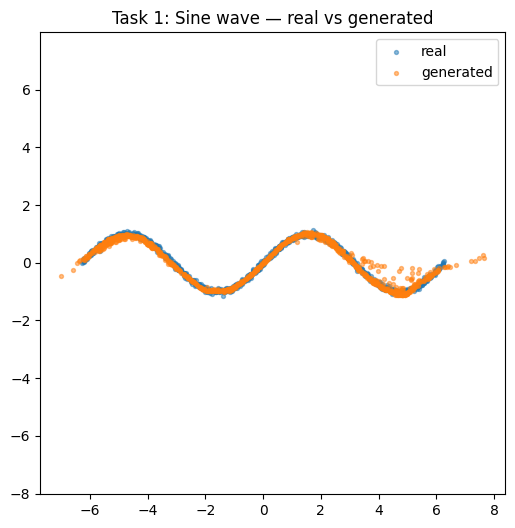

[gmm-baseline] epoch 1000/4000  loss_D=1.249  loss_G=0.943
[gmm-baseline] epoch 2000/4000  loss_D=1.252  loss_G=0.958
[gmm-baseline] epoch 3000/4000  loss_D=1.279  loss_G=0.937
[gmm-baseline] epoch 4000/4000  loss_D=1.267  loss_G=0.959


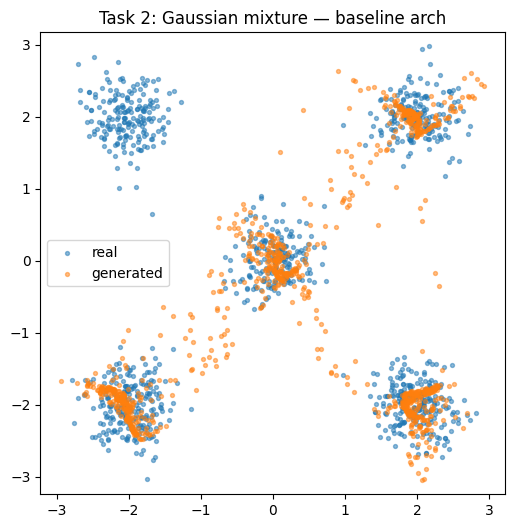

[gmm-modified] epoch 1000/4000  loss_D=1.375  loss_G=0.772
[gmm-modified] epoch 2000/4000  loss_D=1.375  loss_G=0.814
[gmm-modified] epoch 3000/4000  loss_D=1.393  loss_G=0.787
[gmm-modified] epoch 4000/4000  loss_D=1.376  loss_G=0.807


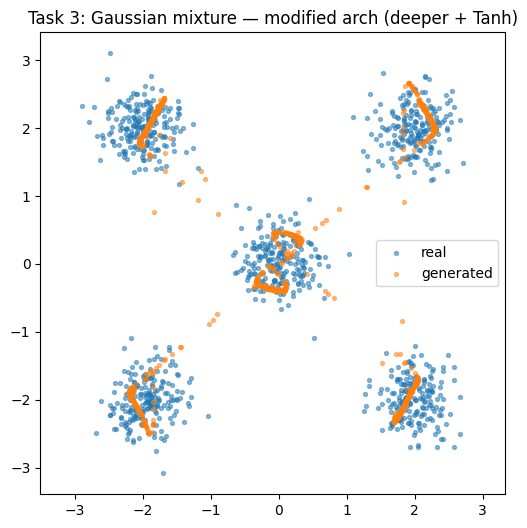

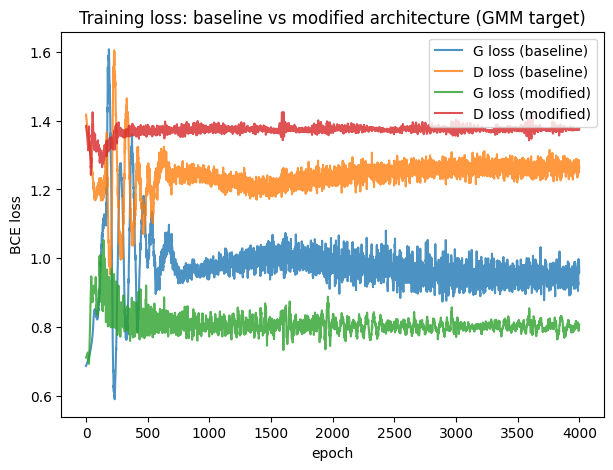


Mode coverage (baseline): [240 202   0 265 221]
Mode coverage (modified): [209 172 197 184 225]


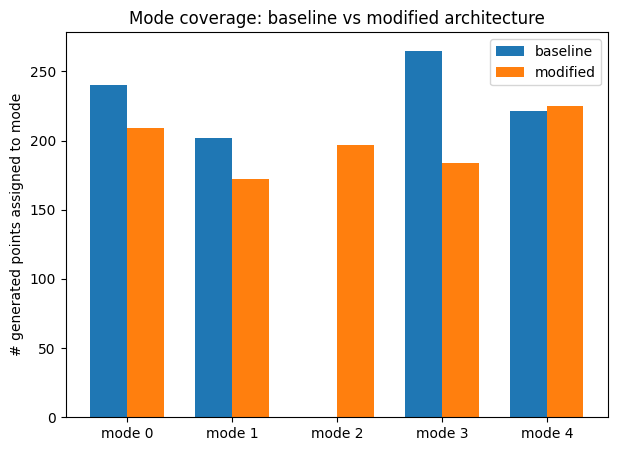


Done. Figures written to ./outputs/ (and shown above)


In [6]:
if __name__ == "__main__":

    # ---- Task 1: reproduce the sine-wave GAN ----
    G_sine, D_sine, gl_s, dl_s = train_gan(sample_sine, name="sine-baseline")
    plot_comparison(sample_sine, G_sine, z_dim=2,
                     title="Task 1: Sine wave — real vs generated",
                     fname="sine_baseline.png")

    # ---- Task 2: new distribution (Gaussian mixture), baseline architecture ----
    G_gmm_base, D_gmm_base, gl_b, dl_b = train_gan(
        sample_gmm, hidden=64, depth=3, gen_act=nn.ReLU, name="gmm-baseline")
    fake_base = plot_comparison(sample_gmm, G_gmm_base, z_dim=2,
                                 title="Task 2: Gaussian mixture — baseline arch",
                                 fname="gmm_baseline.png")

    # ---- Task 3: modified architecture on the SAME distribution ----
    # Modification: deeper network (5 layers vs 3), wider (128 vs 64 hidden
    # units), and Tanh activations in the generator instead of ReLU.
    # Tanh is bounded and smooth, which tends to help a generator trace out
    # several separated modes without "dead" ReLU units killing gradient
    # flow to some of them.
    G_gmm_mod, D_gmm_mod, gl_m, dl_m = train_gan(
        sample_gmm, hidden=128, depth=5, gen_act=nn.Tanh, name="gmm-modified")
    fake_mod = plot_comparison(sample_gmm, G_gmm_mod, z_dim=2,
                                title="Task 3: Gaussian mixture — modified arch (deeper + Tanh)",
                                fname="gmm_modified.png")

    # ---- Loss curves: baseline vs modified ----
    plt.figure(figsize=(7, 5))
    plt.plot(gl_b, label="G loss (baseline)", alpha=0.8)
    plt.plot(dl_b, label="D loss (baseline)", alpha=0.8)
    plt.plot(gl_m, label="G loss (modified)", alpha=0.8)
    plt.plot(dl_m, label="D loss (modified)", alpha=0.8)
    plt.xlabel("epoch")
    plt.ylabel("BCE loss")
    plt.title("Training loss: baseline vs modified architecture (GMM target)")
    plt.legend()
    plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # ---- Mode coverage diagnostic ----
    cov_base = mode_coverage(fake_base)
    cov_mod = mode_coverage(fake_mod)
    print("\nMode coverage (baseline):", cov_base)
    print("Mode coverage (modified):", cov_mod)

    x = np.arange(5)
    width = 0.35
    plt.figure(figsize=(7, 5))
    plt.bar(x - width / 2, cov_base, width, label="baseline")
    plt.bar(x + width / 2, cov_mod, width, label="modified")
    plt.xticks(x, [f"mode {i}" for i in range(5)])
    plt.ylabel("# generated points assigned to mode")
    plt.title("Mode coverage: baseline vs modified architecture")
    plt.legend()
    plt.savefig(os.path.join(OUT_DIR, "mode_coverage.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print("\nDone. Figures written to ./outputs/ (and shown above)")

---
# Shared DCGAN components
Used by Part 2.1 (OCTMNIST) and Part 2.3 (QuickDraw).

Shared DCGAN building blocks for 32x32 single-channel images.
Used by part2_1_octmnist_dcgan.py and part2_3_quickdraw_dcgan.py.

Both OCTMNIST and QuickDraw bitmaps ship as 28x28 grayscale; we pad/resize
to 32x32 so the standard 4-layer DCGAN transpose-conv stack (4 -> 8 -> 16 -> 32)
divides evenly. Both scripts support an optional class-conditioning path
(num_classes > 0) for the conditional-GAN extension task.

In [7]:
import torch
import torch.nn as nn


class DCGenerator(nn.Module):
    def __init__(self, z_dim=100, channels=1, feature_maps=64, num_classes=0):
        super().__init__()
        self.num_classes = num_classes
        in_dim = z_dim + num_classes
        self.net = nn.Sequential(
            # 1x1 -> 4x4
            nn.ConvTranspose2d(in_dim, feature_maps * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),
            # 4x4 -> 8x8
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),
            # 8x8 -> 16x16
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(feature_maps, channels, 4, 2, 1, bias=False),
            nn.Tanh(),  # outputs in [-1, 1] -> match normalised real images
        )

    def forward(self, z, y_onehot=None):
        if self.num_classes > 0:
            assert y_onehot is not None, "num_classes > 0 requires y_onehot"
            z = torch.cat([z, y_onehot], dim=1)
        z = z.view(z.size(0), -1, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, channels=1, feature_maps=64, num_classes=0, img_size=32):
        super().__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        in_ch = channels + num_classes  # class map concatenated as extra channels
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x, y_map=None):
        if self.num_classes > 0:
            assert y_map is not None, "num_classes > 0 requires y_map"
            x = torch.cat([x, y_map], dim=1)
        return self.net(x).view(-1, 1)


def labels_to_map(y_onehot, img_size):
    """Broadcast a (B, num_classes) one-hot vector to (B, num_classes, H, W)
    so it can be concatenated onto the discriminator's input image — the
    standard conditional-DCGAN trick."""
    b, c = y_onehot.shape
    return y_onehot.view(b, c, 1, 1).expand(b, c, img_size, img_size)


def weights_init(m):
    """DCGAN paper's recommended init: N(0, 0.02) for conv/BN weights."""
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

---
# FID utilities
See the docstring below for why this isn't standard ImageNet-Inception FID.

A pragmatic Frechet Distance implementation for this assignment.

Standard "FID" uses a pretrained InceptionV3 (trained on ImageNet, 299x299
RGB natural photos) as the feature extractor. That's a poor fit here for
two reasons:
  1. It requires downloading ~100MB of pretrained weights (needs internet).
  2. Inception's features were learned for natural RGB photos; OCT scans
     and pencil-sketch bitmaps are grayscale and structurally very
     different, so raw ImageNet-Inception features are not a great
     similarity space for them (this is a well-known criticism of using
     vanilla FID outside natural-image domains).

If you *do* have internet access, the standard/comparable-to-literature way
is to `pip install pytorch-fid` and use its Inception-based implementation
directly on your saved real/fake PNGs — do that if you want a number that's
directly comparable to published GAN papers.

As a domain-appropriate, dependency-light substitute, this file computes
the Frechet Distance between real and generated images using features
from a small CNN trained on your OWN real dataset (either a simple
autoencoder bottleneck, or — even simpler and very common in practice —
the trained discriminator's penultimate-layer activations). This still
measures "do real and fake images occupy the same region of some learned
feature space", which is exactly what FID is trying to capture; it's just
a domain-specific feature space rather than ImageNet's.

In [8]:
import numpy as np
import torch
from scipy import linalg


@torch.no_grad()
def extract_features(images, feature_extractor, device, batch_size=128):
    """images: (N, C, H, W) tensor already in the extractor's expected range.
    feature_extractor: a callable returning (N, D) features for a batch."""
    feats = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size].to(device)
        f = feature_extractor(batch)
        feats.append(f.cpu().numpy())
    return np.concatenate(feats, axis=0)


def frechet_distance(feats_real, feats_fake, eps=1e-6):
    """Standard FID formula: ||mu1-mu2||^2 + Tr(C1 + C2 - 2*sqrt(C1*C2))"""
    feats_real = feats_real.astype(np.float64)
    feats_fake = feats_fake.astype(np.float64)
    mu1, sigma1 = feats_real.mean(axis=0), np.cov(feats_real, rowvar=False)
    mu2, sigma2 = feats_fake.mean(axis=0), np.cov(feats_fake, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # numerical stabiliser if sigma1/sigma2 are near-singular (small sample sizes)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
        if np.iscomplexobj(covmean):
            covmean = covmean.real

    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)


def discriminator_feature_extractor(D):
    """Wrap a trained DCDiscriminator (see common_dcgan.py) so it returns
    pooled activations right before its final 1x1 conv, instead of the
    real/fake probability. Cheap way to get a domain-trained feature space
    for FID without any extra training.

    Important: the penultimate conv output is (N, C, 4, 4) — C=256 with the
    default feature_maps=64. Flattening spatial dims too gives a 4096-dim
    feature vector, and frechet_distance()'s scipy.linalg.sqrtm() call scales
    roughly cubically with dimensionality, so that made the FID cell take
    minutes. Global-average-pooling down to (N, C) = (N, 256) first keeps the
    same "which learned feature space are real/fake images in" idea, but
    makes sqrtm() (and the covariance estimate itself, given only ~1000
    samples) both far faster and far more numerically stable.
    """
    penultimate = D.net[:-2]  # drop final Conv2d + Sigmoid
    pool = torch.nn.AdaptiveAvgPool2d(1)

    def extractor(x):
        f = penultimate(x)
        f = pool(f)
        return f.view(f.size(0), -1)

    return extractor

---
# Part 2.1: OCTMNIST DCGAN

Part 2.1 - OCT retinal images with MedMNIST
============================================

Trains a DCGAN (and optionally a conditional DCGAN, see CONDITIONAL flag
below) on OCTMNIST: 28x28 grayscale optical-coherence-tomography retinal
scans in 4 classes (CNV, DME, DRUSEN, NORMAL).

Requirements (not pre-installed in every environment):
    pip install medmnist torch torchvision scipy matplotlib scikit-learn

This script needs internet access the FIRST time it runs (medmnist
auto-downloads the .npz to ~/.medmnist/). If you're offline, download
octmnist.npz manually from https://medmnist.com/ and point DATA_PATH at it.

Run:
    python part2_1_octmnist_dcgan.py

In [14]:
!pip install medmnist
import medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00


In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

### Config

In [10]:
CONDITIONAL = False   # set True for the extension task (class-conditional GAN)
Z_DIM = 100
EPOCHS = 30
BATCH_SIZE = 128
LR = 2e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = "outputs_octmnist"
os.makedirs(OUT_DIR, exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)

### 1. Load + explore OCTMNIST

In [11]:
def load_octmnist():
    from medmnist import OCTMNIST
    train = OCTMNIST(split="train", download=True)
    imgs = train.imgs            # (N, 28, 28) uint8
    labels = train.labels.squeeze()  # (N,)
    return imgs, labels, train.info["label"]


def explore_dataset(imgs, labels, class_names):
    print("Dataset size:", imgs.shape)
    classes, counts = np.unique(labels, return_counts=True)
    print("Class distribution:")
    for c, n in zip(classes, counts):
        print(f"  {class_names[str(c)]:>10s} (label {c}): {n} images "
              f"({100*n/len(labels):.1f}%)")

    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    for c in classes:
        idxs = np.where(labels == c)[0][:8]
        for j, idx in enumerate(idxs):
            axes[c, j].imshow(imgs[idx], cmap="gray")
            axes[c, j].axis("off")
            if j == 0:
                axes[c, j].set_ylabel(class_names[str(c)], rotation=0,
                                       labelpad=40, fontsize=9)
    plt.suptitle("OCTMNIST — sample images per class")
    plt.savefig(os.path.join(OUT_DIR, "sample_grid.png"), dpi=150, bbox_inches="tight")
    plt.show()


def to_tensor_dataset(imgs, labels, num_classes):
    x = torch.from_numpy(imgs).float().unsqueeze(1) / 127.5 - 1.0  # [-1, 1]
    x = F.pad(x, (2, 2, 2, 2))  # 28x28 -> 32x32
    y = torch.from_numpy(labels).long()
    y_onehot = F.one_hot(y, num_classes).float()
    return torch.utils.data.TensorDataset(x, y, y_onehot)

### 2. Train

In [12]:
def train(dataset, num_classes):
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE,
                                          shuffle=True, drop_last=True)
    nc = num_classes if CONDITIONAL else 0
    G = DCGenerator(z_dim=Z_DIM, channels=1, num_classes=nc).to(DEVICE)
    D = DCDiscriminator(channels=1, num_classes=nc, img_size=32).to(DEVICE)
    G.apply(weights_init)
    D.apply(weights_init)

    opt_g = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    g_losses, d_losses = [], []
    for epoch in range(EPOCHS):
        for x, y, y_onehot in loader:
            x, y_onehot = x.to(DEVICE), y_onehot.to(DEVICE)
            b = x.size(0)
            y_map = labels_to_map(y_onehot, 32) if CONDITIONAL else None

            # ---- D step ----
            z = torch.randn(b, Z_DIM, device=DEVICE)
            fake = G(z, y_onehot if CONDITIONAL else None).detach()
            d_real = D(x, y_map)
            d_fake = D(fake, y_map)
            loss_d = criterion(d_real, torch.full_like(d_real, 0.9)) + \
                criterion(d_fake, torch.zeros_like(d_fake))
            opt_d.zero_grad(); loss_d.backward(); opt_d.step()

            # ---- G step ----
            z = torch.randn(b, Z_DIM, device=DEVICE)
            fake = G(z, y_onehot if CONDITIONAL else None)
            d_fake = D(fake, y_map)
            loss_g = criterion(d_fake, torch.ones_like(d_fake))
            opt_g.zero_grad(); loss_g.backward(); opt_g.step()

            g_losses.append(loss_g.item())
            d_losses.append(loss_d.item())

        print(f"epoch {epoch+1}/{EPOCHS}  loss_D={loss_d.item():.3f}  loss_G={loss_g.item():.3f}")

        if (epoch + 1) % 5 == 0:
            save_sample_grid(G, num_classes, f"epoch_{epoch+1:03d}.png")

    plt.figure()
    plt.plot(g_losses, label="G loss")
    plt.plot(d_losses, label="D loss")
    plt.xlabel("iteration"); plt.legend(); plt.title("OCTMNIST DCGAN training loss")
    plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
    plt.show()

    return G, D


@torch.no_grad()
def save_sample_grid(G, num_classes, fname, n=16):
    z = torch.randn(n, Z_DIM, device=DEVICE)
    if CONDITIONAL:
        y = torch.arange(n) % num_classes
        y_onehot = F.one_hot(y, num_classes).float().to(DEVICE)
        fake = G(z, y_onehot)
    else:
        fake = G(z)
    fake = (fake.cpu() + 1) / 2  # back to [0,1]
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake[i, 0], cmap="gray")
        ax.axis("off")
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def generate_class(G, class_idx, num_classes, n=16):
    """Extension task: generate n samples from a specific requested class."""
    assert CONDITIONAL, "generate_class requires CONDITIONAL=True"
    z = torch.randn(n, Z_DIM, device=DEVICE)
    y = torch.full((n,), class_idx, dtype=torch.long)
    y_onehot = F.one_hot(y, num_classes).float().to(DEVICE)
    fake = G(z, y_onehot)
    return (fake.cpu() + 1) / 2

### 3. Evaluate: real vs fake, FID

Dataset size: (97477, 28, 28)
Class distribution:
  choroidal neovascularization (label 0): 33484 images (34.4%)
  diabetic macular edema (label 1): 10213 images (10.5%)
      drusen (label 2): 7754 images (8.0%)
      normal (label 3): 46026 images (47.2%)


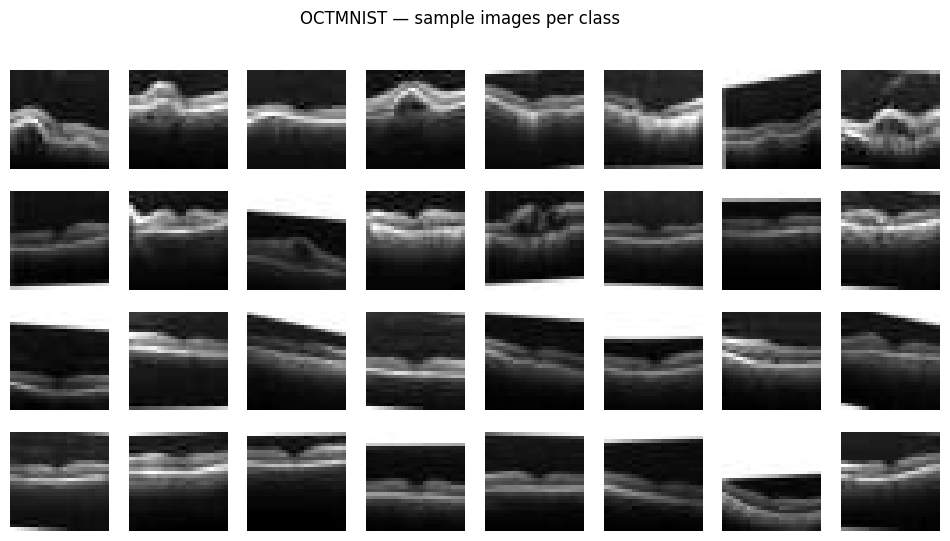

epoch 1/30  loss_D=0.584  loss_G=2.507
epoch 2/30  loss_D=0.791  loss_G=2.443
epoch 3/30  loss_D=0.514  loss_G=1.823
epoch 4/30  loss_D=1.318  loss_G=1.398
epoch 5/30  loss_D=0.758  loss_G=3.511


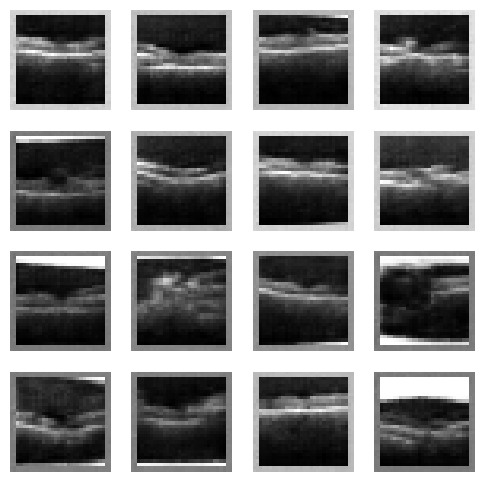

epoch 6/30  loss_D=0.578  loss_G=2.062
epoch 7/30  loss_D=0.532  loss_G=2.203
epoch 8/30  loss_D=0.682  loss_G=1.969
epoch 9/30  loss_D=0.398  loss_G=3.302
epoch 10/30  loss_D=0.496  loss_G=2.848


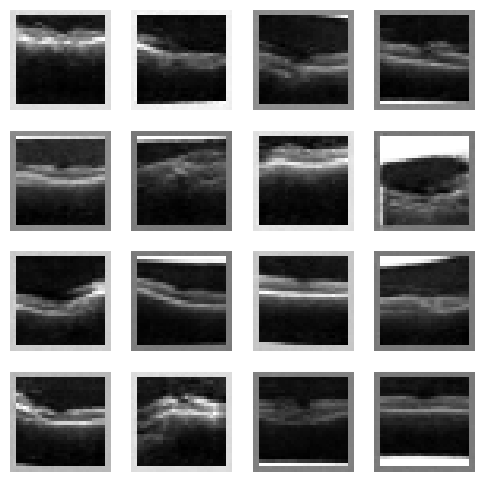

epoch 11/30  loss_D=0.603  loss_G=2.357
epoch 12/30  loss_D=0.423  loss_G=3.686
epoch 13/30  loss_D=0.478  loss_G=2.757
epoch 14/30  loss_D=0.398  loss_G=5.148
epoch 15/30  loss_D=0.487  loss_G=2.432


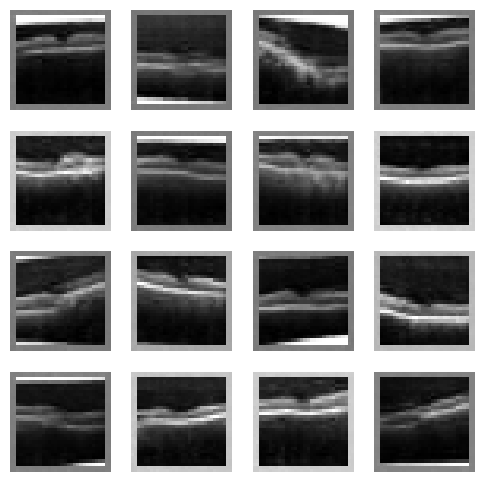

epoch 16/30  loss_D=0.605  loss_G=2.372
epoch 17/30  loss_D=0.434  loss_G=3.520
epoch 18/30  loss_D=0.563  loss_G=2.283
epoch 19/30  loss_D=0.468  loss_G=3.313
epoch 20/30  loss_D=0.408  loss_G=3.107


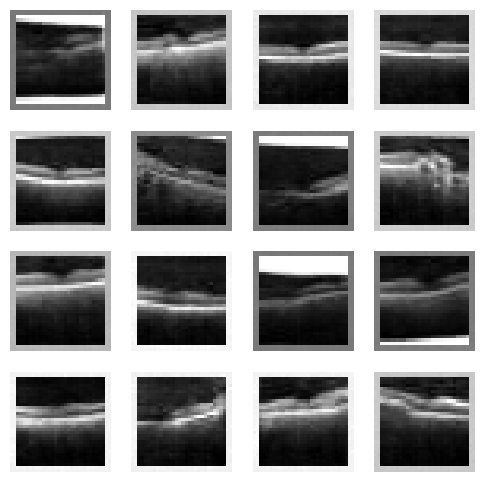

epoch 21/30  loss_D=0.461  loss_G=3.283
epoch 22/30  loss_D=0.421  loss_G=2.960
epoch 23/30  loss_D=0.598  loss_G=3.489
epoch 24/30  loss_D=0.403  loss_G=3.679
epoch 25/30  loss_D=0.403  loss_G=3.946


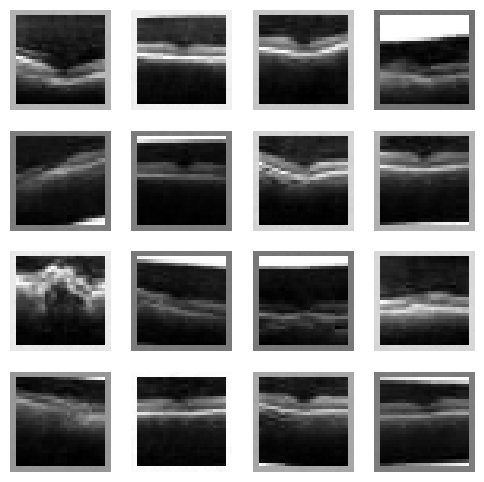

epoch 26/30  loss_D=0.405  loss_G=4.348
epoch 27/30  loss_D=0.428  loss_G=4.511
epoch 28/30  loss_D=0.377  loss_G=4.598
epoch 29/30  loss_D=0.430  loss_G=4.280
epoch 30/30  loss_D=0.365  loss_G=4.445


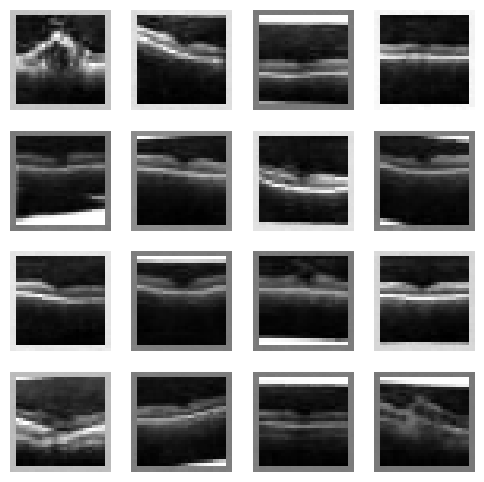

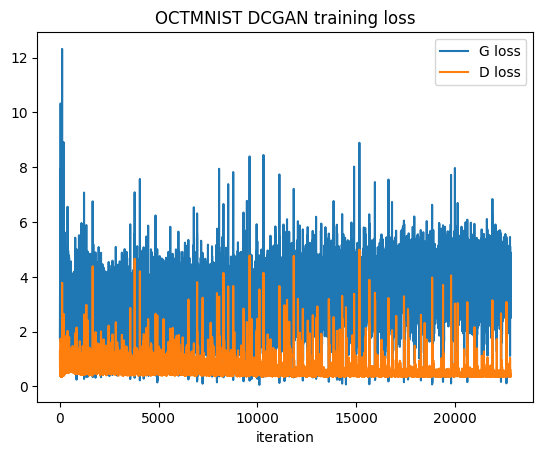


Frechet distance (discriminator-feature space, NOT ImageNet-Inception FID): 1.02
Lower = generated and real images occupy more similar regions of the learned feature space. Not comparable to Inception-FID numbers in papers — see fid_utils.py docstring.

Done. See ./outputs_octmnist/


/tmp/ipykernel_2778/1965879171.py:26: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


In [17]:
def evaluate(G, D, dataset, num_classes):
    real_x = torch.stack([dataset[i][0] for i in
                           np.random.choice(len(dataset), 1000, replace=False)])
    z = torch.randn(1000, Z_DIM, device=DEVICE)
    if CONDITIONAL:
        y = torch.randint(0, num_classes, (1000,))
        y_onehot = F.one_hot(y, num_classes).float().to(DEVICE)
        with torch.no_grad():
            fake_x = G(z, y_onehot).cpu()
    else:
        with torch.no_grad():
            fake_x = G(z).cpu()

    extractor = discriminator_feature_extractor(D)
    feats_real = extract_features((real_x.to(DEVICE) + 1) / 2 * 2 - 1, extractor, DEVICE)
    feats_fake = extract_features(fake_x.to(DEVICE), extractor, DEVICE)
    fid = frechet_distance(feats_real, feats_fake)
    print(f"\nFrechet distance (discriminator-feature space, NOT ImageNet-Inception FID): {fid:.2f}")
    print("Lower = generated and real images occupy more similar regions of "
          "the learned feature space. Not comparable to Inception-FID numbers "
          "in papers — see fid_utils.py docstring.")
    return fid


# ---------------------------------------------------------------------------
if __name__ == "__main__":
    imgs, labels, class_names = load_octmnist()
    explore_dataset(imgs, labels, class_names)
    num_classes = len(class_names)
    dataset = to_tensor_dataset(imgs, labels, num_classes)

    G, D = train(dataset, num_classes)
    evaluate(G, D, dataset, num_classes)

    if CONDITIONAL:
        for c in range(num_classes):
            samples = generate_class(G, c, num_classes)
            fig, axes = plt.subplots(2, 4, figsize=(8, 4))
            for i, ax in enumerate(axes.flat):
                ax.imshow(samples[i, 0], cmap="gray")
                ax.axis("off")
            plt.suptitle(f"Generated: class {class_names[str(c)]}")
            plt.savefig(os.path.join(OUT_DIR, f"conditional_class_{c}.png"),
                        dpi=150, bbox_inches="tight")
            plt.show()

    print("\nDone. See ./outputs_octmnist/")

---
# Part 2.2: CICIDS2017 tabular GAN

Part 2.2 - Cybersecurity: synthetic traffic with CICIDS2017
=============================================================

Trains a simple MLP GAN to generate synthetic CICIDS2017 feature vectors
(BENIGN + DDoS traffic from the Wednesday capture), then compares real vs
generated distributions with PCA/t-SNE.

Data: download the CICIDS2017 CSVs from
https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset/data
and point DATA_DIR at the folder containing the per-day CSVs, e.g.:
    Monday-WorkingHours.pcap_ISCX.csv
    Tuesday-WorkingHours.pcap_ISCX.csv
    Wednesday-workingHours.pcap_ISCX.csv       <- used for the main task
    Thursday-*.csv, Friday-*.csv (several files) <- used only for the extension

Requirements:
    pip install torch pandas numpy scikit-learn matplotlib

Run:
    python part2_2_cicids_gan.py

In [16]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

DATA_DIR = "./cicids2017"          # <-- point at your downloaded CSV folder
OUT_DIR = "outputs_cicids"
os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

In [31]:
!pip install kaggle --upgrade

In [32]:
# Set Kaggle credentials from Colab secrets (if used)
import os
from google.colab import userdata

# Create the data directory if it doesn't exist
DATA_DIR = './cicids2017'  # Ensure this matches the DATA_DIR in the original notebook
os.makedirs(DATA_DIR, exist_ok=True)

# Download the dataset
!kaggle datasets download -d chethuhn/network-intrusion-dataset -p {DATA_DIR}

# Unzip the downloaded file
zip_file_path = os.path.join(DATA_DIR, 'network-intrusion-dataset.zip')
!unzip -o {zip_file_path} -d {DATA_DIR}

print(f"Dataset downloaded and extracted to {DATA_DIR}/")
print("Please verify that 'Wednesday-workingHours.pcap_ISCX.csv' exists in this directory before rerunning the evaluation cell.")

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
network-intrusion-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ./cicids2017/network-intrusion-dataset.zip
  inflating: ./cicids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  
  inflating: ./cicids2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  
  inflating: ./cicids2017/Friday-WorkingHours-Morning.pcap_ISCX.csv  
  inflating: ./cicids2017/Monday-WorkingHours.pcap_ISCX.csv  
  inflating: ./cicids2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  
  inflating: ./cicids2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  
  inflating: ./cicids2017/Tuesday-WorkingHours.pcap_ISCX.csv  
  inflating: ./cicids2017/Wednesday-workingHours.pcap_ISCX.csv  
Dataset downloaded and extracted to ./cicids2017/
Please verify that 'Wednesday-workingHours.pcap_ISCX.csv' exists in this directory before rerun

### 1. Load + explore

In [20]:
def load_all_days(data_dir=DATA_DIR):
    """Extension helper: load and concatenate every day's CSV."""
    paths = sorted(glob.glob(os.path.join(data_dir, "*.csv")))
    if not paths:
        raise FileNotFoundError(f"No CSVs found in {data_dir} — download CICIDS2017 first.")
    frames = []
    for p in paths:
        df = pd.read_csv(p, low_memory=False)
        df.columns = df.columns.str.strip()
        df["source_file"] = os.path.basename(p)
        frames.append(df)
        print(f"Loaded {p}: {df.shape}")
    return pd.concat(frames, ignore_index=True)


def load_wednesday(data_dir=DATA_DIR):
    """Main task: Wednesday only (BENIGN + DoS/DDoS labels)."""
    candidates = glob.glob(os.path.join(data_dir, "Wednesday*.csv"))
    if not candidates:
        raise FileNotFoundError("Wednesday CSV not found — check DATA_DIR.")
    df = pd.read_csv(candidates[0], low_memory=False)
    df.columns = df.columns.str.strip()
    return df


def explore(df):
    print("Shape:", df.shape)
    print("\nClass balance:")
    print(df["Label"].value_counts())

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(f"\n{len(numeric_cols)} numeric feature columns")
    return numeric_cols


def clean_and_scale(df, numeric_cols, label_col="Label"):
    df = df.copy()
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=numeric_cols)

    # collapse to binary BENIGN vs ATTACK for a clean class-conditioning signal
    df["binary_label"] = (df[label_col].str.upper() != "BENIGN").astype(int)

    X = df[numeric_cols].values.astype(np.float32)
    y = df["binary_label"].values.astype(np.int64)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y, scaler

### 2. Tabular GAN (simple MLP)

In [21]:
class Generator(nn.Module):
    def __init__(self, z_dim, out_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.ReLU(True),
            nn.Linear(hidden, hidden), nn.ReLU(True),
            nn.Linear(hidden, out_dim),  # no final activation: data is standardised, unbounded
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, in_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


def train_gan(X, z_dim=32, epochs=200, batch_size=256, lr=2e-4):
    X_t = torch.from_numpy(X).to(DEVICE)
    n, d = X_t.shape
    G = Generator(z_dim, d).to(DEVICE)
    D = Discriminator(d).to(DEVICE)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    g_losses, d_losses = [], []
    for epoch in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n - batch_size, batch_size):
            real = X_t[perm[i:i + batch_size]]
            b = real.size(0)

            z = torch.randn(b, z_dim, device=DEVICE)
            fake = G(z).detach()
            d_real = D(real)
            d_fake = D(fake)
            loss_d = criterion(d_real, torch.full_like(d_real, 0.9)) + \
                criterion(d_fake, torch.zeros_like(d_fake))
            opt_d.zero_grad(); loss_d.backward(); opt_d.step()

            z = torch.randn(b, z_dim, device=DEVICE)
            fake = G(z)
            d_fake = D(fake)
            loss_g = criterion(d_fake, torch.ones_like(d_fake))
            opt_g.zero_grad(); loss_g.backward(); opt_g.step()

            g_losses.append(loss_g.item())
            d_losses.append(loss_d.item())

        if (epoch + 1) % 20 == 0:
            print(f"epoch {epoch+1}/{epochs}  loss_D={loss_d.item():.3f}  loss_G={loss_g.item():.3f}")

    plt.figure()
    plt.plot(g_losses, label="G loss")
    plt.plot(d_losses, label="D loss")
    plt.legend(); plt.xlabel("iteration"); plt.title("CICIDS2017 tabular GAN training loss")
    plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
    plt.show()

    return G, D, z_dim

### 3. Evaluate: PCA / t-SNE real vs synthetic

Shape: (692703, 79)

Class balance:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

78 numeric feature columns
epoch 20/200  loss_D=0.971  loss_G=2.508
epoch 40/200  loss_D=0.750  loss_G=2.603
epoch 60/200  loss_D=0.820  loss_G=3.427
epoch 80/200  loss_D=0.702  loss_G=3.312
epoch 100/200  loss_D=0.748  loss_G=1.958
epoch 120/200  loss_D=0.744  loss_G=2.591
epoch 140/200  loss_D=0.729  loss_G=3.420
epoch 160/200  loss_D=0.466  loss_G=5.520
epoch 180/200  loss_D=0.647  loss_G=5.414
epoch 200/200  loss_D=0.469  loss_G=6.371


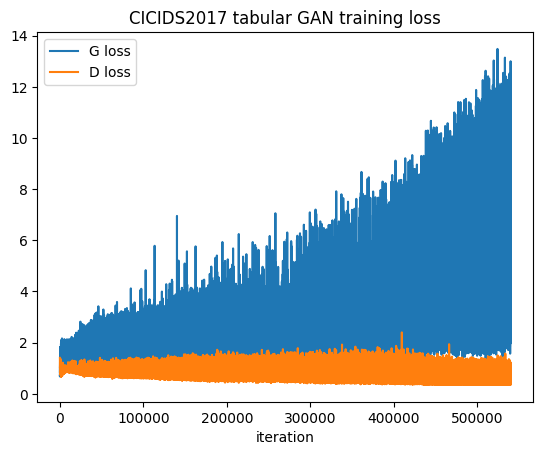

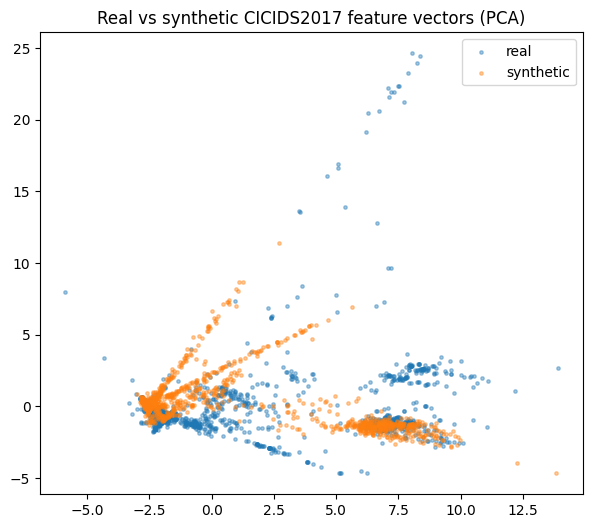

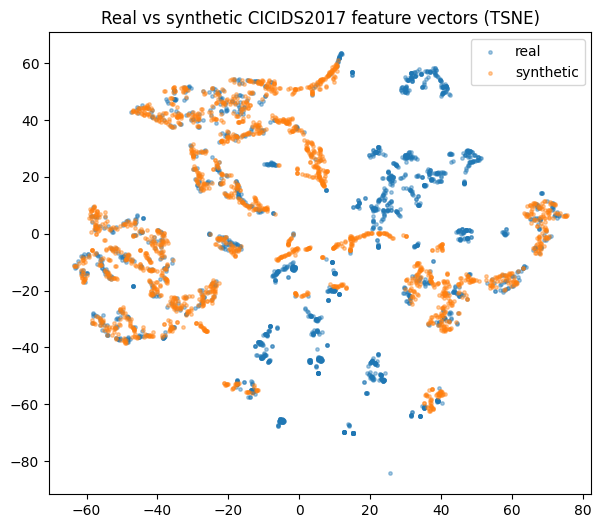

Mean |real_mean - fake_mean| across features: 0.115
Mean |real_std  - fake_std | across features: 0.480
Mean nearest-real-neighbour distance for synthetic points: 1.933

Done. See ./outputs_cicids/

Extension: call load_all_days() instead of load_wednesday(), repeat clean_and_scale/train_gan per attack type in df['Label'], and compare per-attack-type PCA plots to see which attack distributions the GAN generalises to well vs poorly.


In [22]:
@torch.no_grad()
def generate_samples(G, z_dim, n):
    z = torch.randn(n, z_dim, device=DEVICE)
    return G(z).cpu().numpy()


def compare_distributions(X_real, X_fake, n_plot=2000, method="pca"):
    idx_r = np.random.choice(len(X_real), min(n_plot, len(X_real)), replace=False)
    idx_f = np.random.choice(len(X_fake), min(n_plot, len(X_fake)), replace=False)
    real = X_real[idx_r]
    fake = X_fake[idx_f]
    combined = np.vstack([real, fake])

    if method == "pca":
        proj = PCA(n_components=2).fit_transform(combined)
    else:
        proj = TSNE(n_components=2, perplexity=30, init="pca").fit_transform(combined)

    n_r = len(real)
    plt.figure(figsize=(7, 6))
    plt.scatter(proj[:n_r, 0], proj[:n_r, 1], s=6, alpha=0.4, label="real")
    plt.scatter(proj[n_r:, 0], proj[n_r:, 1], s=6, alpha=0.4, label="synthetic")
    plt.legend()
    plt.title(f"Real vs synthetic CICIDS2017 feature vectors ({method.upper()})")
    plt.savefig(os.path.join(OUT_DIR, f"{method}_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()


def alignment_metrics(X_real, X_fake):
    """Simple, interpretable alignment checks alongside the PCA/t-SNE plots:
    per-feature mean/std discrepancy, and mean nearest-neighbour distance
    from each synthetic point to the real set."""
    mean_diff = np.abs(X_real.mean(0) - X_fake.mean(0)).mean()
    std_diff = np.abs(X_real.std(0) - X_fake.std(0)).mean()
    print(f"Mean |real_mean - fake_mean| across features: {mean_diff:.3f}")
    print(f"Mean |real_std  - fake_std | across features: {std_diff:.3f}")

    from sklearn.neighbors import NearestNeighbors
    nn_model = NearestNeighbors(n_neighbors=1).fit(X_real[:5000])
    sample_fake = X_fake[np.random.choice(len(X_fake), min(2000, len(X_fake)), replace=False)]
    dists, _ = nn_model.kneighbors(sample_fake)
    print(f"Mean nearest-real-neighbour distance for synthetic points: {dists.mean():.3f}")


# ---------------------------------------------------------------------------
if __name__ == "__main__":
    df = load_wednesday()
    numeric_cols = explore(df)
    X, y, scaler = clean_and_scale(df, numeric_cols)

    G, D, z_dim = train_gan(X)
    X_fake = generate_samples(G, z_dim, n=len(X))

    compare_distributions(X, X_fake, method="pca")
    compare_distributions(X, X_fake, method="tsne")
    alignment_metrics(X, X_fake)

    print("\nDone. See ./outputs_cicids/")
    print("\nExtension: call load_all_days() instead of load_wednesday(), "
          "repeat clean_and_scale/train_gan per attack type in df['Label'], "
          "and compare per-attack-type PCA plots to see which attack "
          "distributions the GAN generalises to well vs poorly.")

---
# Part 2.3: QuickDraw 'birthday cake' DCGAN

Part 2.3 - Creative AI: QuickDraw 'birthday cake' subset
==========================================================

Trains a DCGAN on the QuickDraw "birthday cake" category (28x28 grayscale
bitmap sketches), then extends to other categories for extra credit.

Data: download the pre-rasterised numpy bitmaps (28x28, already centred/
normalised — no need to parse raw stroke JSON) from:
    https://console.cloud.google.com/storage/browser/quickdraw_dataset/full/numpy_bitmap
or via gsutil, e.g.:
    gsutil -m cp "gs://quickdraw_dataset/full/numpy_bitmap/birthday cake.npy" ./quickdraw_data/
Repo overview: https://github.com/googlecreativelab/quickdraw-dataset

Requirements:
    pip install torch numpy matplotlib scipy

Run:
    python part2_3_quickdraw_dcgan.py

In [23]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

### Config

In [24]:
DATA_DIR = "./quickdraw_data"           # <-- folder holding the .npy bitmap files
PRIMARY_CATEGORY = "birthday cake"
EXTENSION_CATEGORIES = ["cat", "house"]  # extra credit: other categories
Z_DIM = 100
EPOCHS = 25
BATCH_SIZE = 128
LR = 2e-4
MAX_SAMPLES = 20000    # QuickDraw categories can have 100k+ sketches; subsample for speed
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

### 1. Load + explore

In [25]:
def load_category(name, data_dir=DATA_DIR, max_samples=MAX_SAMPLES):
    path = os.path.join(data_dir, f"{name}.npy")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found — download it from the QuickDraw numpy_bitmap bucket first.")
    imgs = np.load(path)  # (N, 784) uint8, flattened 28x28
    imgs = imgs.reshape(-1, 28, 28)
    if len(imgs) > max_samples:
        idx = np.random.choice(len(imgs), max_samples, replace=False)
        imgs = imgs[idx]
    return imgs


def explore(imgs, name, out_dir):
    print(f"'{name}': {imgs.shape[0]} sketches, {imgs.shape[1]}x{imgs.shape[2]} px")
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    idxs = np.random.choice(len(imgs), 16, replace=False)
    for ax, idx in zip(axes.flat, idxs):
        ax.imshow(imgs[idx], cmap="gray_r")
        ax.axis("off")
    plt.suptitle(f"QuickDraw sample: {name}")
    plt.savefig(os.path.join(out_dir, f"sample_grid_{name.replace(' ', '_')}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def to_tensor_dataset(imgs):
    x = torch.from_numpy(imgs).float().unsqueeze(1) / 127.5 - 1.0  # [-1, 1]
    x = F.pad(x, (2, 2, 2, 2))  # 28x28 -> 32x32
    return torch.utils.data.TensorDataset(x)

### 2. Train a DCGAN on one category

In [26]:
def train(dataset, out_dir, tag):
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE,
                                          shuffle=True, drop_last=True)
    G = DCGenerator(z_dim=Z_DIM, channels=1).to(DEVICE)
    D = DCDiscriminator(channels=1, img_size=32).to(DEVICE)
    G.apply(weights_init)
    D.apply(weights_init)

    opt_g = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    g_losses, d_losses = [], []
    for epoch in range(EPOCHS):
        for (x,) in loader:
            x = x.to(DEVICE)
            b = x.size(0)

            z = torch.randn(b, Z_DIM, device=DEVICE)
            fake = G(z).detach()
            d_real = D(x)
            d_fake = D(fake)
            loss_d = criterion(d_real, torch.full_like(d_real, 0.9)) + \
                criterion(d_fake, torch.zeros_like(d_fake))
            opt_d.zero_grad(); loss_d.backward(); opt_d.step()

            z = torch.randn(b, Z_DIM, device=DEVICE)
            fake = G(z)
            d_fake = D(fake)
            loss_g = criterion(d_fake, torch.ones_like(d_fake))
            opt_g.zero_grad(); loss_g.backward(); opt_g.step()

            g_losses.append(loss_g.item())
            d_losses.append(loss_d.item())

        print(f"[{tag}] epoch {epoch+1}/{EPOCHS}  loss_D={loss_d.item():.3f}  loss_G={loss_g.item():.3f}")
        if (epoch + 1) % 5 == 0:
            save_sample_grid(G, out_dir, f"{tag}_epoch_{epoch+1:03d}.png")

    plt.figure()
    plt.plot(g_losses, label="G loss")
    plt.plot(d_losses, label="D loss")
    plt.legend(); plt.xlabel("iteration"); plt.title(f"QuickDraw '{tag}' DCGAN training loss")
    plt.savefig(os.path.join(out_dir, f"{tag}_loss_curve.png"), dpi=150, bbox_inches="tight")
    plt.show()

    return G, D


@torch.no_grad()
def save_sample_grid(G, out_dir, fname, n=16):
    z = torch.randn(n, Z_DIM, device=DEVICE)
    fake = (G(z).cpu() + 1) / 2
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake[i, 0], cmap="gray_r")
        ax.axis("off")
    plt.savefig(os.path.join(out_dir, fname), dpi=150, bbox_inches="tight")
    plt.show()

### 3. Evaluate

In [29]:
import os

DATA_DIR = './quickdraw_data'
PRIMARY_CATEGORY = 'birthday cake'
EXTENSION_CATEGORIES = ['cat', 'house']

os.makedirs(DATA_DIR, exist_ok=True)

print(f"Downloading {PRIMARY_CATEGORY}.npy...")
!gsutil -m cp "gs://quickdraw_dataset/full/numpy_bitmap/{PRIMARY_CATEGORY}.npy" {DATA_DIR}/

for category in EXTENSION_CATEGORIES:
    print(f"Downloading {category}.npy...")
    !gsutil -m cp "gs://quickdraw_dataset/full/numpy_bitmap/{category}.npy" {DATA_DIR}/

print("QuickDraw dataset files downloaded. You can now re-run the evaluation cell for QuickDraw.")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/numpy_bitmap/birthday cake.npy...
- [1/1 files][108.4 MiB/108.4 MiB] 100% Done                                    
Operation completed over 1 objects/108.4 MiB.                                    
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/numpy_bitmap/cat.npy...
\ [1/1 files][ 92.1 MiB/ 92.1 MiB] 100% Done                                    
Operation completed over 1 objects/92.1 MiB.                                     
Google recommends using Gc

'birthday cake': 20000 sketches, 28x28 px


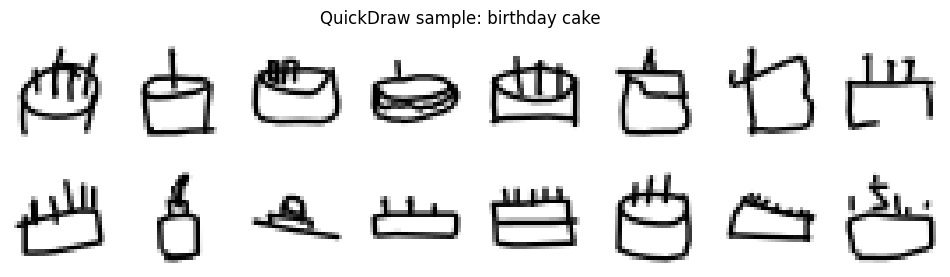

[birthday_cake] epoch 1/25  loss_D=0.739  loss_G=8.879
[birthday_cake] epoch 2/25  loss_D=0.411  loss_G=3.901
[birthday_cake] epoch 3/25  loss_D=0.381  loss_G=4.232
[birthday_cake] epoch 4/25  loss_D=0.369  loss_G=3.898
[birthday_cake] epoch 5/25  loss_D=0.405  loss_G=3.694


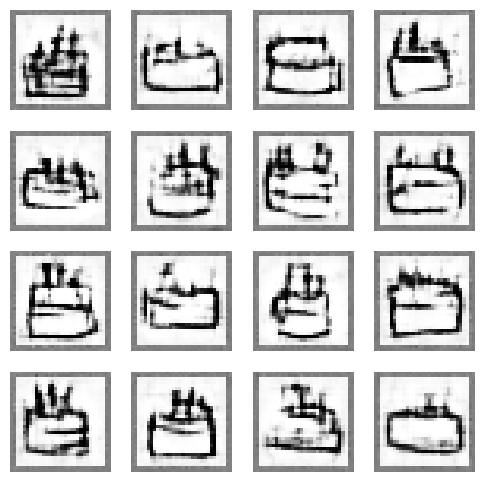

[birthday_cake] epoch 6/25  loss_D=0.426  loss_G=4.280
[birthday_cake] epoch 7/25  loss_D=0.477  loss_G=2.953
[birthday_cake] epoch 8/25  loss_D=0.450  loss_G=3.146
[birthday_cake] epoch 9/25  loss_D=0.406  loss_G=3.226
[birthday_cake] epoch 10/25  loss_D=0.468  loss_G=3.634


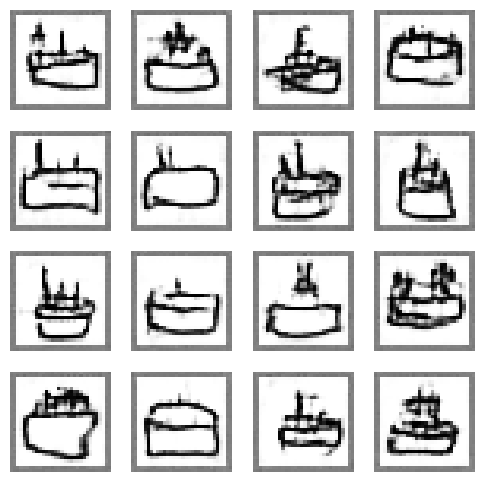

[birthday_cake] epoch 11/25  loss_D=4.365  loss_G=1.817
[birthday_cake] epoch 12/25  loss_D=0.397  loss_G=3.403
[birthday_cake] epoch 13/25  loss_D=0.538  loss_G=1.475
[birthday_cake] epoch 14/25  loss_D=0.430  loss_G=3.307
[birthday_cake] epoch 15/25  loss_D=0.469  loss_G=3.019


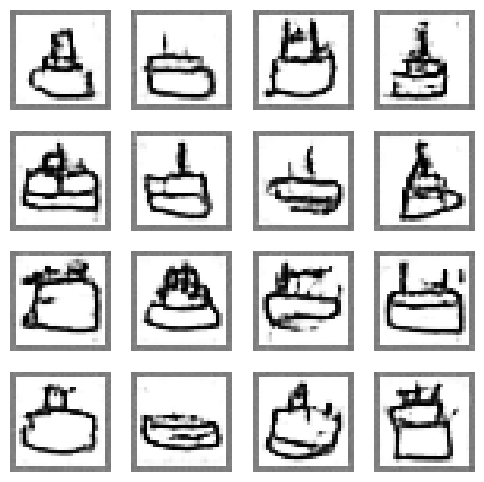

[birthday_cake] epoch 16/25  loss_D=0.425  loss_G=4.387
[birthday_cake] epoch 17/25  loss_D=0.776  loss_G=4.913
[birthday_cake] epoch 18/25  loss_D=0.406  loss_G=4.548
[birthday_cake] epoch 19/25  loss_D=0.440  loss_G=1.897
[birthday_cake] epoch 20/25  loss_D=0.416  loss_G=4.648


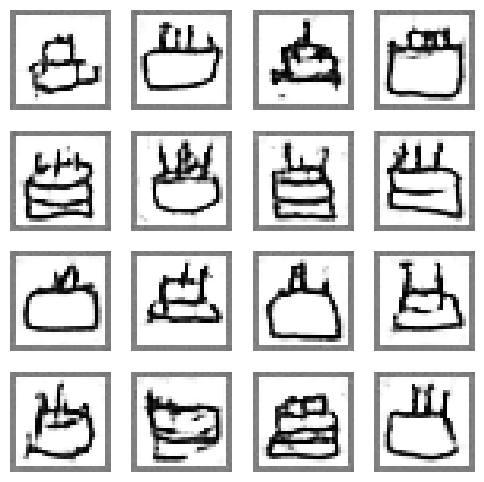

[birthday_cake] epoch 21/25  loss_D=0.996  loss_G=1.313
[birthday_cake] epoch 22/25  loss_D=0.430  loss_G=4.222
[birthday_cake] epoch 23/25  loss_D=0.461  loss_G=2.878
[birthday_cake] epoch 24/25  loss_D=0.381  loss_G=4.524
[birthday_cake] epoch 25/25  loss_D=0.723  loss_G=1.403


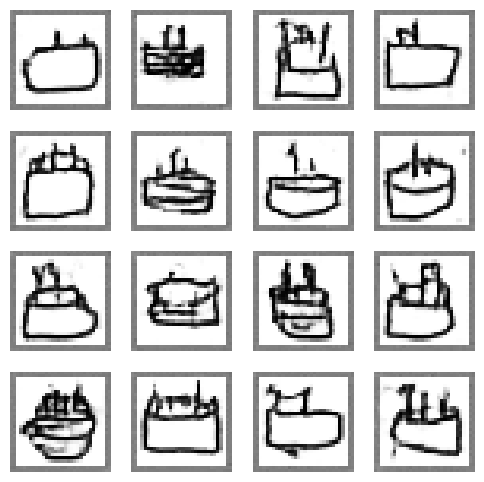

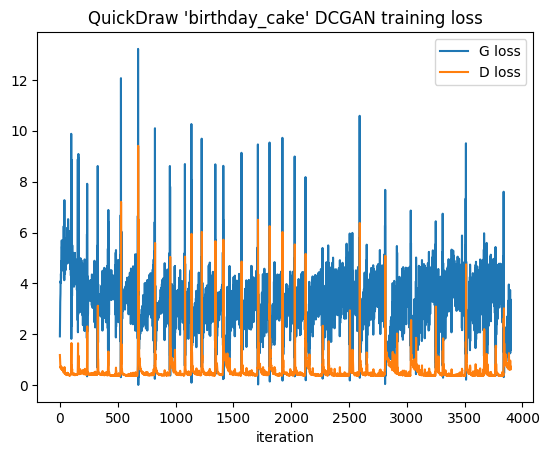

/tmp/ipykernel_2778/1965879171.py:26: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


Frechet distance (discriminator-feature space): 0.52
'cat': 20000 sketches, 28x28 px


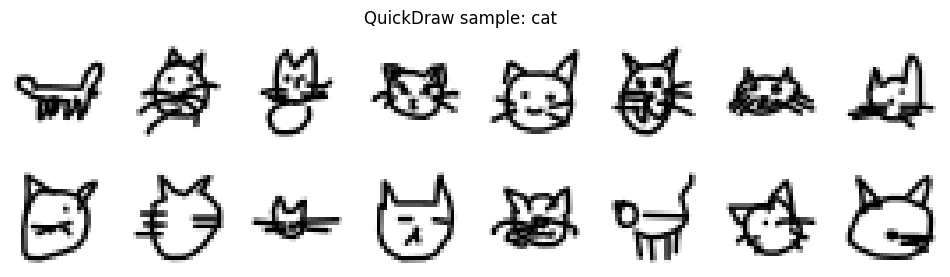

[cat] epoch 1/25  loss_D=0.482  loss_G=4.263
[cat] epoch 2/25  loss_D=0.414  loss_G=3.561
[cat] epoch 3/25  loss_D=0.411  loss_G=3.619
[cat] epoch 4/25  loss_D=0.369  loss_G=4.398
[cat] epoch 5/25  loss_D=2.012  loss_G=9.210


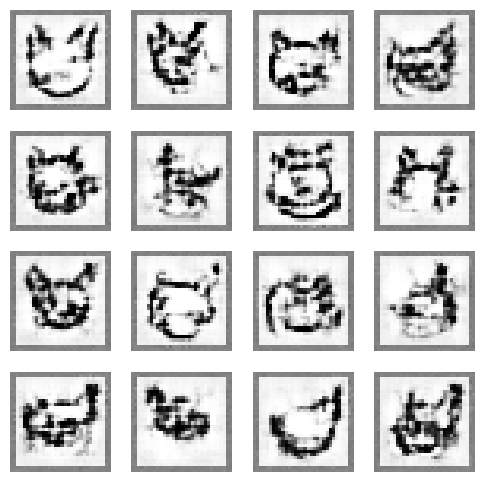

[cat] epoch 6/25  loss_D=0.422  loss_G=4.188
[cat] epoch 7/25  loss_D=0.453  loss_G=3.591
[cat] epoch 8/25  loss_D=0.413  loss_G=2.967
[cat] epoch 9/25  loss_D=0.467  loss_G=3.057
[cat] epoch 10/25  loss_D=0.440  loss_G=3.018


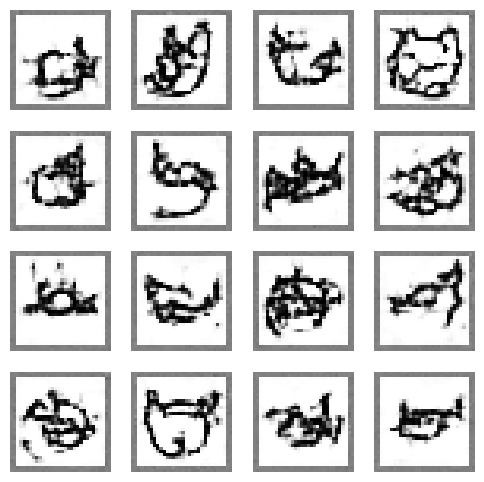

[cat] epoch 11/25  loss_D=0.505  loss_G=2.247
[cat] epoch 12/25  loss_D=1.394  loss_G=0.288
[cat] epoch 13/25  loss_D=1.000  loss_G=1.305
[cat] epoch 14/25  loss_D=0.493  loss_G=3.561
[cat] epoch 15/25  loss_D=0.996  loss_G=5.905


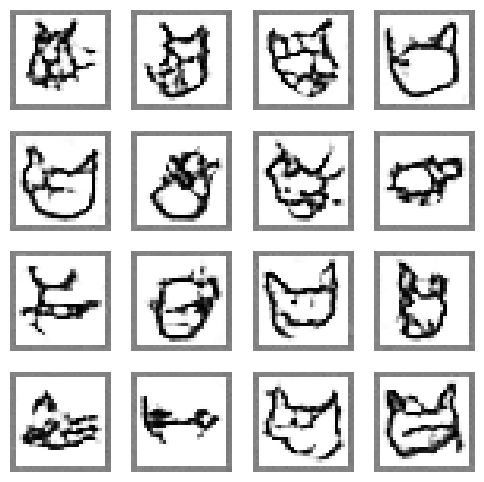

[cat] epoch 16/25  loss_D=0.493  loss_G=3.906
[cat] epoch 17/25  loss_D=0.425  loss_G=3.877
[cat] epoch 18/25  loss_D=0.420  loss_G=2.905
[cat] epoch 19/25  loss_D=0.543  loss_G=2.073
[cat] epoch 20/25  loss_D=0.399  loss_G=3.656


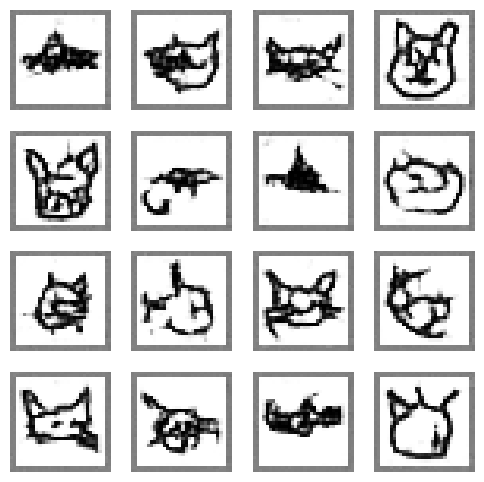

[cat] epoch 21/25  loss_D=0.382  loss_G=3.800
[cat] epoch 22/25  loss_D=0.526  loss_G=1.916
[cat] epoch 23/25  loss_D=0.370  loss_G=4.499
[cat] epoch 24/25  loss_D=0.795  loss_G=0.395
[cat] epoch 25/25  loss_D=0.376  loss_G=4.041


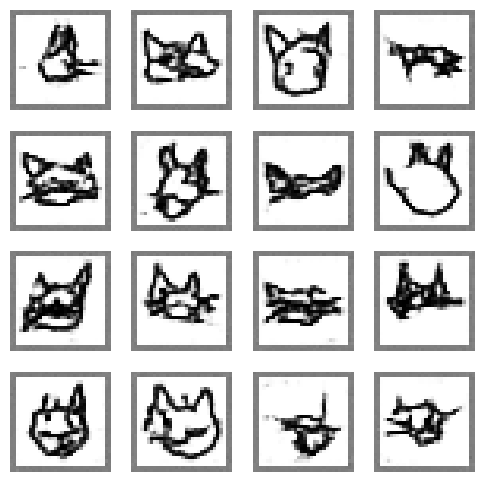

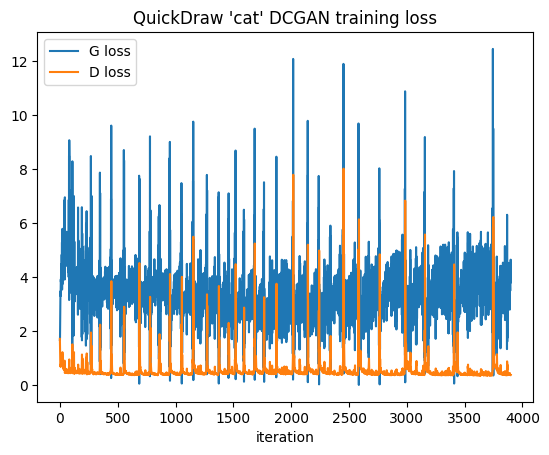

Frechet distance (discriminator-feature space): 0.54
'house': 20000 sketches, 28x28 px


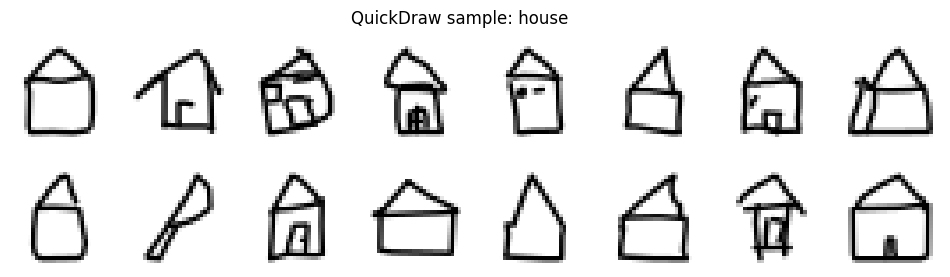

[house] epoch 1/25  loss_D=0.406  loss_G=4.795
[house] epoch 2/25  loss_D=0.416  loss_G=3.341
[house] epoch 3/25  loss_D=0.390  loss_G=3.766
[house] epoch 4/25  loss_D=0.399  loss_G=3.614
[house] epoch 5/25  loss_D=0.372  loss_G=4.167


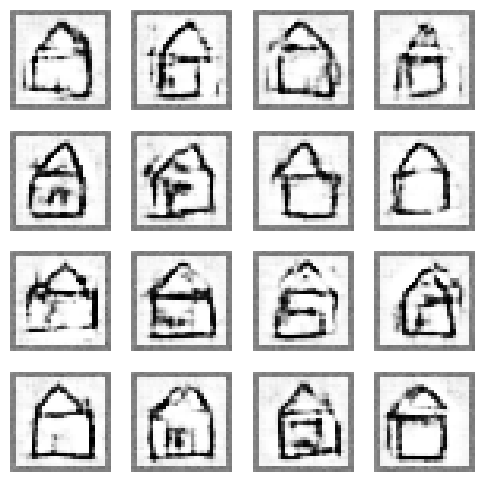

[house] epoch 6/25  loss_D=0.357  loss_G=4.718
[house] epoch 7/25  loss_D=0.405  loss_G=3.749
[house] epoch 8/25  loss_D=0.400  loss_G=3.583
[house] epoch 9/25  loss_D=0.403  loss_G=3.269
[house] epoch 10/25  loss_D=0.410  loss_G=2.898


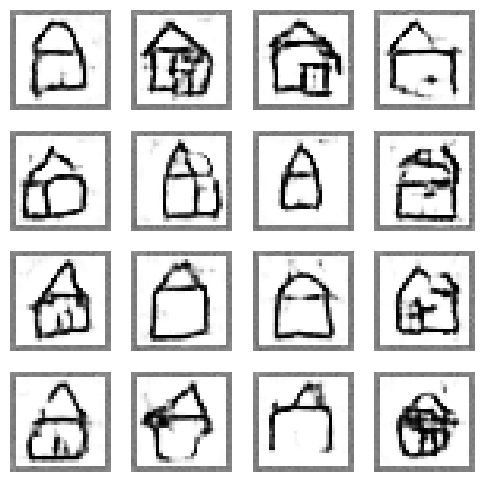

[house] epoch 11/25  loss_D=0.397  loss_G=3.540
[house] epoch 12/25  loss_D=0.372  loss_G=5.150
[house] epoch 13/25  loss_D=0.371  loss_G=4.207
[house] epoch 14/25  loss_D=0.382  loss_G=3.972
[house] epoch 15/25  loss_D=0.739  loss_G=1.457


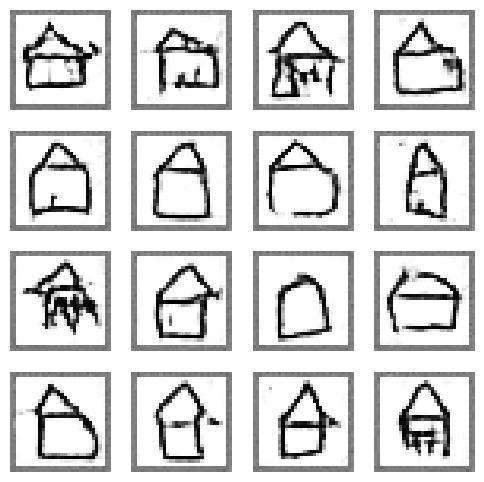

[house] epoch 16/25  loss_D=0.419  loss_G=4.346
[house] epoch 17/25  loss_D=0.396  loss_G=4.753
[house] epoch 18/25  loss_D=1.615  loss_G=1.165
[house] epoch 19/25  loss_D=3.215  loss_G=7.281
[house] epoch 20/25  loss_D=0.436  loss_G=3.823


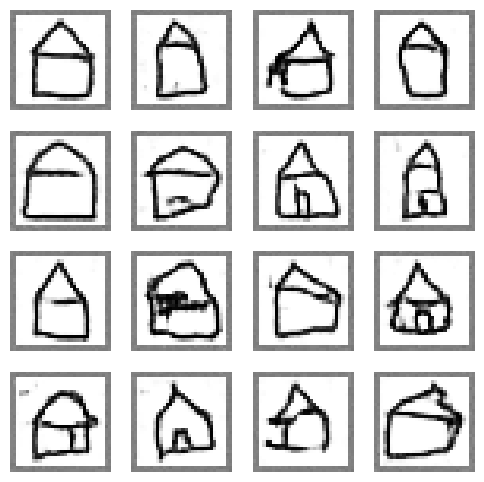

[house] epoch 21/25  loss_D=0.605  loss_G=3.211
[house] epoch 22/25  loss_D=0.410  loss_G=3.733
[house] epoch 23/25  loss_D=0.577  loss_G=4.385
[house] epoch 24/25  loss_D=0.416  loss_G=4.366
[house] epoch 25/25  loss_D=0.409  loss_G=2.669


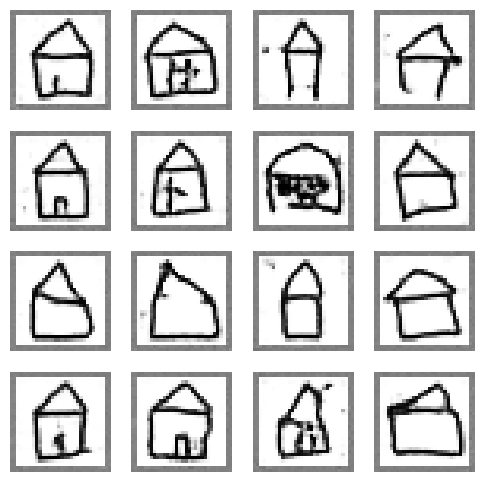

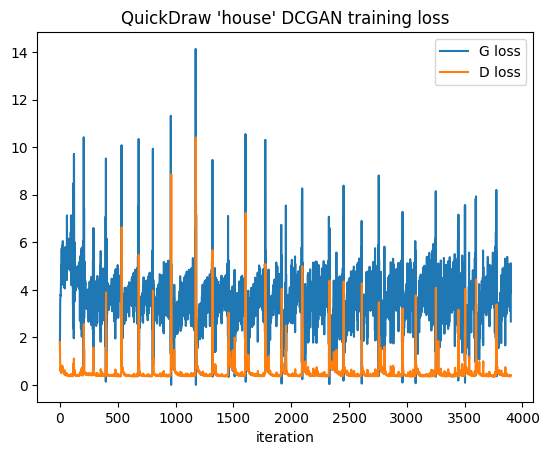

Frechet distance (discriminator-feature space): 0.65

Frechet distance by category (lower = better match, discriminator-feature space, not cross-comparable to Inception-FID):
    birthday cake: 0.52
              cat: 0.54
            house: 0.65

Done. See ./outputs_quickdraw/


In [30]:
def evaluate(G, D, dataset):
    real_x = torch.stack([dataset[i][0] for i in
                           np.random.choice(len(dataset), min(1000, len(dataset)), replace=False)])
    z = torch.randn(len(real_x), Z_DIM, device=DEVICE)
    with torch.no_grad():
        fake_x = G(z).cpu()

    extractor = discriminator_feature_extractor(D)
    feats_real = extract_features(real_x.to(DEVICE), extractor, DEVICE)
    feats_fake = extract_features(fake_x.to(DEVICE), extractor, DEVICE)
    fid = frechet_distance(feats_real, feats_fake)
    print(f"Frechet distance (discriminator-feature space): {fid:.2f}")
    return fid


# ---------------------------------------------------------------------------
if __name__ == "__main__":
    out_dir = "outputs_quickdraw"
    os.makedirs(out_dir, exist_ok=True)

    # ---- main task: birthday cake ----
    imgs = load_category(PRIMARY_CATEGORY)
    explore(imgs, PRIMARY_CATEGORY, out_dir)
    dataset = to_tensor_dataset(imgs)
    G, D = train(dataset, out_dir, tag=PRIMARY_CATEGORY.replace(" ", "_"))
    fid_cake = evaluate(G, D, dataset)

    # ---- extension: other categories ----
    results = {PRIMARY_CATEGORY: fid_cake}
    for cat in EXTENSION_CATEGORIES:
        try:
            imgs_c = load_category(cat)
        except FileNotFoundError as e:
            print(e); continue
        explore(imgs_c, cat, out_dir)
        dataset_c = to_tensor_dataset(imgs_c)
        G_c, D_c = train(dataset_c, out_dir, tag=cat.replace(" ", "_"))
        results[cat] = evaluate(G_c, D_c, dataset_c)

    print("\nFrechet distance by category (lower = better match, "
          "discriminator-feature space, not cross-comparable to Inception-FID):")
    for cat, fid in results.items():
        print(f"  {cat:>15s}: {fid:.2f}")

    print("\nDone. See ./outputs_quickdraw/")